In [169]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [170]:
# df = pd.read_csv("./data/df_final_janeiro_22.csv")
df = pd.read_csv("./data/df_filtrado_pelo_dbcsan.csv")
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos,cluster
0,3.0,71.0,1.0,4.0,1.0,2.0,2.0,5.0,2.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,1.0,1.0,0.0,65
1,1.0,46.0,1.0,1.0,1.0,1.0,3.0,8.0,2.0,1.0,...,2.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,40
2,2.0,54.0,2.0,4.0,2.0,1.0,6.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,261
3,2.0,42.0,2.0,4.0,2.0,1.0,2.0,4.0,1.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,3.0,202
4,2.0,68.0,1.0,4.0,2.0,1.0,5.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,3.0,52.0,1.0,4.0,2.0,1.0,6.0,6.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0,207
1308,1.0,73.0,1.0,2.0,2.0,2.0,5.0,10.0,3.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,2.0,182
1309,3.0,53.0,2.0,4.0,4.0,1.0,1.0,5.0,1.0,2.0,...,2.0,2.0,2.0,2.0,6.0,3.0,1.0,0.0,3.0,102
1310,4.0,80.0,1.0,1.0,4.0,2.0,4.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,65


In [171]:
# df = df.drop(columns=["Estado_Civil", "Apoio_Familiar", "Qtd_Comodos"])
df = df.drop(columns=["Estado_Civil", "Apoio_Familiar", "Qtd_Comodos", "cluster"])
# df = df.drop(columns=["cluster"])
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Nivel_Instrucao,Total_Moradores,Qtd_Banheiros,Possui_Automovel,Possui_Computador,Acesso_Internet,...,Freq_Anedonia,Freq_Depressao,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Amigos
0,3.0,71.0,1.0,4.0,2.0,2.0,2.0,1.0,2.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,3.0,3.0,1.0,0.0
1,1.0,46.0,1.0,1.0,1.0,3.0,2.0,1.0,1.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,2.0,3.0,3.0,2.0
2,2.0,54.0,2.0,4.0,1.0,6.0,3.0,1.0,1.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,3.0,3.0,2.0,2.0
3,2.0,42.0,2.0,4.0,1.0,2.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0
4,2.0,68.0,1.0,4.0,1.0,5.0,3.0,1.0,1.0,1.0,...,3.0,1.0,2.0,2.0,2.0,1.0,3.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,3.0,52.0,1.0,4.0,1.0,6.0,1.0,2.0,2.0,1.0,...,3.0,2.0,1.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0
1308,1.0,73.0,1.0,2.0,2.0,5.0,3.0,1.0,1.0,1.0,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0
1309,3.0,53.0,2.0,4.0,1.0,1.0,1.0,2.0,2.0,1.0,...,1.0,2.0,2.0,2.0,2.0,2.0,6.0,3.0,1.0,3.0
1310,4.0,80.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,2.0,...,1.0,1.0,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0


In [172]:
# target = "Saude_Boa"
target = "Autoavaliacao_Saude"

In [118]:
df['Saude_Boa'] = df['Autoavaliacao_Saude'].map({
    1: 1,  # Muito boa
    2: 1,  # Boa
    3: 0,  # Regular
    4: 0,  # Ruim
    5: 0   # Muito ruim
})
df

,Autoavaliacao_Saude,Idade,Sexo,Cor_Raca,Estado_Civil,Nivel_Instrucao,Total_Moradores,Qtd_Comodos,Qtd_Banheiros,Possui_Automovel,...,Grau_Limite_Depressao,Grau_Limite_Doenca_Mental,Grau_Limite_DORT,Pratica_Exercicio,Horas_TV,Fuma,Freq_Alcool,Apoio_Familiar,Apoio_Amigos,Saude_Boa
0,3.0,71.0,1.0,4.0,1.0,2.0,2.0,5.0,2.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,1.0,1.0,0.0,0
1,1.0,46.0,1.0,1.0,1.0,1.0,3.0,8.0,2.0,1.0,...,2.0,2.0,2.0,1.0,2.0,3.0,3.0,3.0,2.0,1
2,2.0,54.0,2.0,4.0,2.0,1.0,6.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,1
3,2.0,42.0,2.0,4.0,2.0,1.0,2.0,4.0,1.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,2.0,3.0,3.0,1
4,2.0,68.0,1.0,4.0,2.0,1.0,5.0,7.0,3.0,1.0,...,2.0,2.0,2.0,1.0,3.0,3.0,2.0,3.0,2.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,3.0,52.0,1.0,4.0,2.0,1.0,6.0,6.0,1.0,2.0,...,1.0,2.0,2.0,2.0,1.0,1.0,1.0,3.0,3.0,0
1308,1.0,73.0,1.0,2.0,2.0,2.0,5.0,10.0,3.0,1.0,...,2.0,2.0,2.0,1.0,1.0,3.0,3.0,3.0,2.0,1
1309,3.0,53.0,2.0,4.0,4.0,1.0,1.0,5.0,1.0,2.0,...,2.0,2.0,2.0,2.0,6.0,3.0,1.0,0.0,3.0,0
1310,4.0,80.0,1.0,1.0,4.0,2.0,4.0,5.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,3.0,1.0,3.0,3.0,0


Separando X e Y

In [173]:
X = df.drop(columns=[target, "Autoavaliacao_Saude"])
y = df[target]


Fazendo onehot encoding

In [174]:
cols_nominais = [
    'Cor_Raca',
    'Possui_Automovel', 'Possui_Computador',
    'Acesso_Internet',
    'Pratica_Exercicio', 'Fuma'
]

X = pd.get_dummies(X, columns=cols_nominais, drop_first=True)

In [175]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42, stratify=y)

Utilizando CatBoostRegressor + SHAP

In [176]:
from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    random_seed=42,
    verbose=100,
    
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

y_pred = model.predict(X_test)

0:	learn: 0.5632345	test: 0.5723342	best: 0.5723342 (0)	total: 3.57ms	remaining: 2.85s
100:	learn: 0.3465224	test: 0.4522407	best: 0.4519921 (99)	total: 115ms	remaining: 794ms
200:	learn: 0.3061261	test: 0.4571904	best: 0.4519921 (99)	total: 191ms	remaining: 569ms
300:	learn: 0.2743602	test: 0.4656549	best: 0.4519921 (99)	total: 272ms	remaining: 451ms
400:	learn: 0.2505729	test: 0.4720755	best: 0.4519921 (99)	total: 394ms	remaining: 392ms
500:	learn: 0.2324041	test: 0.4749478	best: 0.4519921 (99)	total: 488ms	remaining: 291ms
600:	learn: 0.2187474	test: 0.4789705	best: 0.4519921 (99)	total: 618ms	remaining: 205ms
700:	learn: 0.2092601	test: 0.4825616	best: 0.4519921 (99)	total: 733ms	remaining: 104ms
799:	learn: 0.2012600	test: 0.4837929	best: 0.4519921 (99)	total: 829ms	remaining: 0us

bestTest = 0.4519920886
bestIteration = 99

Shrink model to first 100 iterations.


In [177]:
y_pred = model.predict(X_test)
y_pred = y_pred.clip(1, 5).round()

mae = mean_absolute_error(y_test, y_pred)
print("MAE final:", mae)


MAE final: 0.39847715736040606


In [168]:
import numpy as np
from sklearn.metrics import cohen_kappa_score
from scipy.optimize import minimize

def neg_qwk(thresholds, y_true, y_pred_cont):
    thresholds = np.sort(thresholds)  
    y_pred_disc = np.digitize(y_pred_cont, thresholds) + 1
    return -cohen_kappa_score(y_true, y_pred_disc, weights="quadratic")

init_thresholds = [1.5, 2.5, 3.5, 4.5]

res = minimize(
    neg_qwk,
    init_thresholds,
    args=(y_test, y_pred),
    method='Powell'
)

best_thresholds = np.sort(res.x)
print("Thresholds otimizados:", best_thresholds)

y_pred_opt = np.digitize(y_pred, best_thresholds) + 1

qwk_opt = cohen_kappa_score(y_test, y_pred_opt, weights="quadratic")
print("QWK otimizado:", qwk_opt)


Thresholds otimizados: [-0.09942806  2.5         3.5         4.5       ]
QWK otimizado: 0.44935117662674307


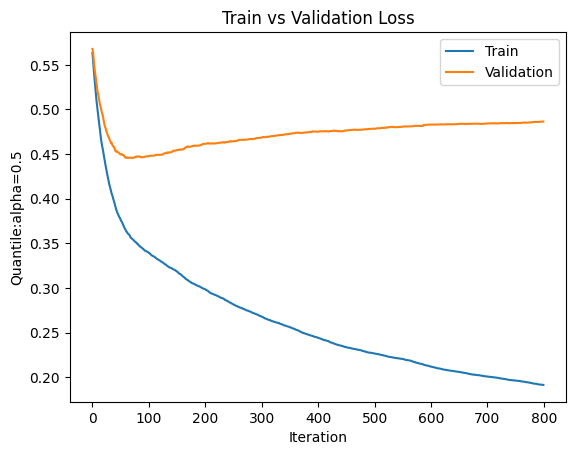

In [101]:
evals = model.get_evals_result()

train_loss = evals['learn']["MAE"]
val_loss   = evals['validation']["MAE"]

plt.figure()
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.xlabel("Iteration")
plt.ylabel("Quantile:alpha=0.5")
plt.legend()
plt.title("Train vs Validation Loss")
plt.show()


In [178]:
importances = model.get_feature_importance()
features = X_train.columns

imp_df = (
    pd.DataFrame({
        "feature": features,
        "importance": importances
    })
    .query("importance >= 0.5")
    .sort_values("importance", ascending=False)
)

print(imp_df.head(20))


                  feature  importance
0                   Idade   22.687571
20  Possui_Computador_2.0   10.287635
22  Pratica_Exercicio_2.0    9.863696
5     Freq_Problemas_Sono    7.056811
19   Possui_Automovel_2.0    6.049755
13            Freq_Alcool    5.832029
14           Apoio_Amigos    5.817894
3         Total_Moradores    5.411163
12               Horas_TV    4.355347
4           Qtd_Banheiros    3.533801
6            Freq_Cansaco    3.445069
8          Freq_Depressao    3.355646
7           Freq_Anedonia    3.290288
2         Nivel_Instrucao    3.259117
21    Acesso_Internet_2.0    1.609039
17           Cor_Raca_4.0    1.045722
15           Cor_Raca_2.0    0.787202
24               Fuma_3.0    0.693499
1                    Sexo    0.602571


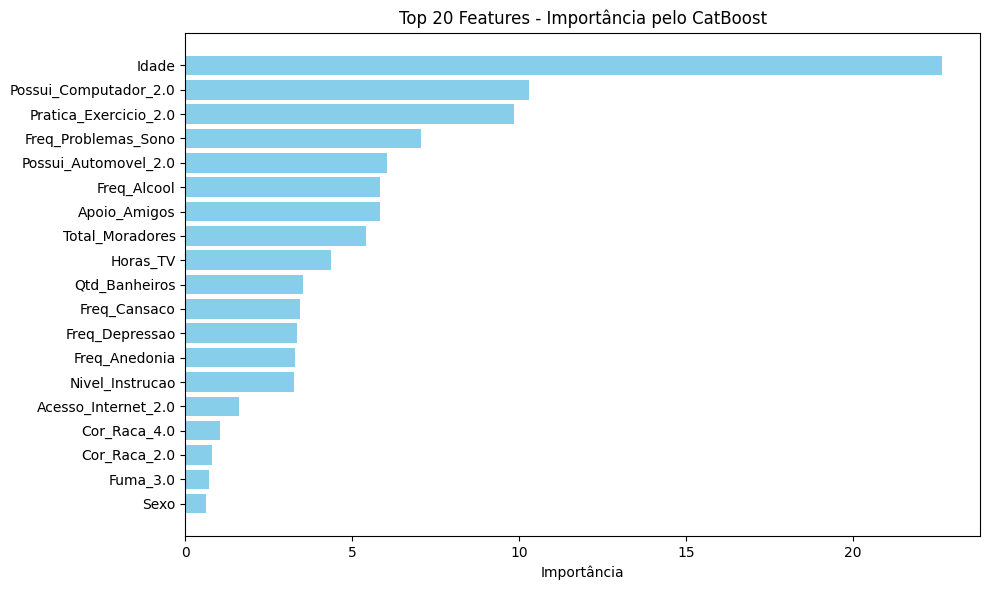

In [181]:
import matplotlib.pyplot as plt

imp_df_top20 = imp_df.head(20).sort_values("importance")

plt.figure(figsize=(10,6))
plt.barh(imp_df_top20["feature"], imp_df_top20["importance"], color="skyblue")
plt.xlabel("Importância")
plt.title("Top 20 Features - Importância pelo CatBoost")
plt.tight_layout()
plt.show()


fazendo cross validação

0:	learn: 0.5818956	test: 0.5830097	best: 0.5830097 (0)	total: 14.2ms	remaining: 11.3s
1:	learn: 0.5784140	test: 0.5793838	best: 0.5793838 (1)	total: 19.1ms	remaining: 7.63s
2:	learn: 0.5745620	test: 0.5754585	best: 0.5754585 (2)	total: 23.9ms	remaining: 6.35s
3:	learn: 0.5712877	test: 0.5722052	best: 0.5722052 (3)	total: 28.4ms	remaining: 5.65s
4:	learn: 0.5678566	test: 0.5688935	best: 0.5688935 (4)	total: 40.4ms	remaining: 6.42s
5:	learn: 0.5646198	test: 0.5655648	best: 0.5655648 (5)	total: 46.4ms	remaining: 6.15s
6:	learn: 0.5613985	test: 0.5622719	best: 0.5622719 (6)	total: 50.4ms	remaining: 5.71s
7:	learn: 0.5577101	test: 0.5585960	best: 0.5585960 (7)	total: 55.3ms	remaining: 5.48s
8:	learn: 0.5549148	test: 0.5557423	best: 0.5557423 (8)	total: 60.2ms	remaining: 5.29s
9:	learn: 0.5521503	test: 0.5531848	best: 0.5531848 (9)	total: 63.6ms	remaining: 5.02s
10:	learn: 0.5496652	test: 0.5506354	best: 0.5506354 (10)	total: 72.1ms	remaining: 5.17s
11:	learn: 0.5470319	test: 0.5480218	best

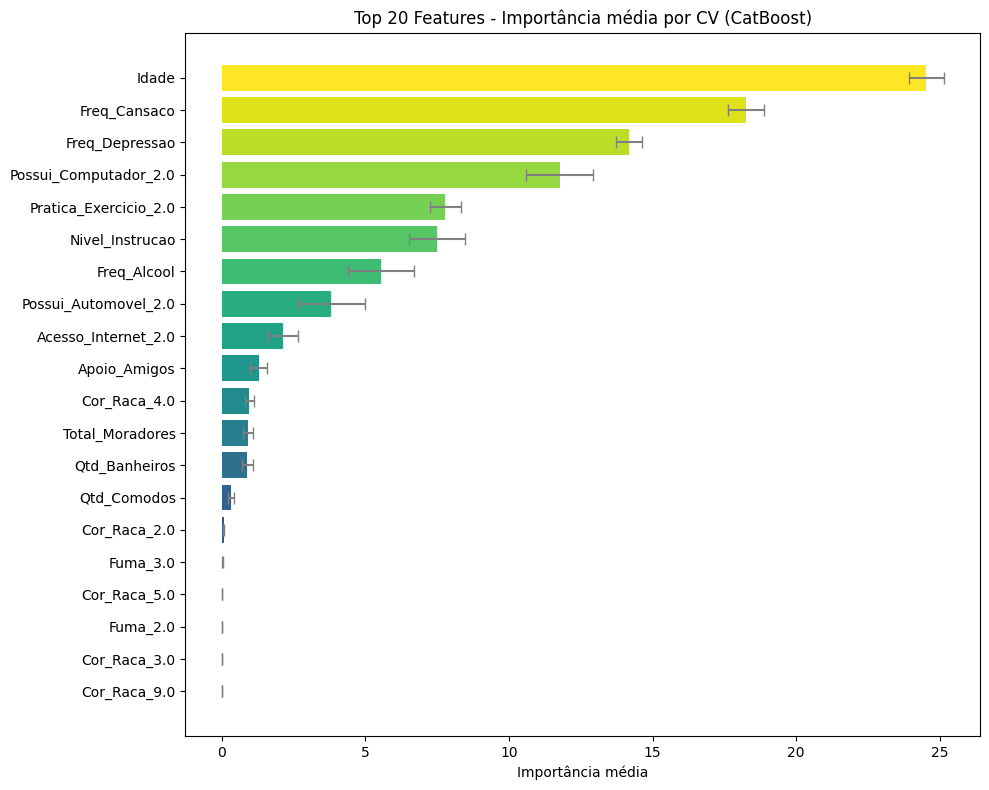

In [24]:
params = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'MAE',
    'eval_metric': 'MAE',
    'random_seed': 42,
    'verbose': True
}


n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

feature_importances = []
fold = 1

for train_index, val_index in kf.split(X):
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    model = CatBoostRegressor(**params)
    model.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        use_best_model=True,
    )

    importances = model.get_feature_importance()
    feature_importances.append(importances)
    best_iter = model.get_best_iteration()
    best_score = model.get_best_score()['validation']['MAE']

    print(f"Fold {fold}: Melhor iteração = {best_iter}, Melhor loss no eval_set = {best_score:.4f}")
    fold += 1

# Média e desvio padrão das importâncias
importances_mean = np.mean(feature_importances, axis=0)
importances_std = np.std(feature_importances, axis=0)

imp_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': importances_mean,
    'importance_std': importances_std
}).sort_values('importance_mean', ascending=False)

top20 = imp_df.head(20).sort_values('importance_mean')

colors = cm.viridis(np.linspace(0, 1, len(top20)))

plt.figure(figsize=(10,8))
plt.barh(
    top20['feature'],
    top20['importance_mean'],
    xerr=top20['importance_std'],
    color=colors,
    ecolor='gray',
    capsize=4
)
plt.xlabel('Importância média')
plt.title('Top 20 Features - Importância média por CV (CatBoost)')
plt.gca()
plt.tight_layout()
plt.show()


Fazendo Clusterização com as melhores Variáveis do SHAP

In [130]:
features_cluster = [
    "Diagnostico_Doenca_Cronica",
    "Idade",
    "Freq_Cansaco",
    "Pratica_Exercicio",
    "Freq_Depressao",
    "Freq_Problemas_Sono",
    "Nivel_Instrucao",
    "Freq_Alcool",
    "Freq_Anedonia",
    "Possui_Computador",
    "Possui_Automovel"
]

X_cluster = df[features_cluster]

In [131]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

Utilizando K-means

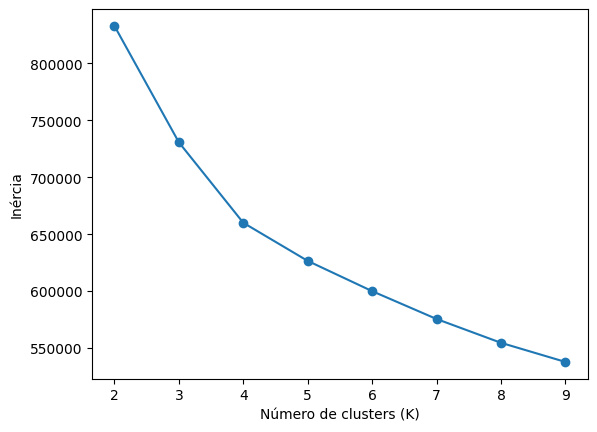

In [132]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inércia")
plt.show()


In [136]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
df["cluster"] = kmeans.fit_predict(X_scaled)
df["cluster"].value_counts()

cluster
3    29678
1    24570
0    23377
2    13221
Name: count, dtype: int64

In [137]:
cluster_profile = (
    df.groupby("cluster")[features_cluster]
      .mean()
      .round(2)
)

cluster_profile

,Diagnostico_Doenca_Cronica,Idade,Freq_Cansaco,Pratica_Exercicio,Freq_Depressao,Freq_Problemas_Sono,Nivel_Instrucao,Freq_Alcool,Freq_Anedonia,Possui_Computador,Possui_Automovel
cluster,,,,,,,,,,,
0,1.13,64.15,1.36,1.77,1.25,1.68,1.80,1.25,1.22,1.86,1.71
1,1.51,41.69,1.39,1.32,1.17,1.42,1.17,1.94,1.20,1.06,1.19
2,1.21,46.51,3.08,1.69,2.68,3.02,1.42,1.56,2.75,1.68,1.64
3,1.84,36.25,1.28,1.65,1.18,1.25,1.19,1.79,1.19,1.94,1.76


In [138]:
import pandas as pd

crosstab_norm = pd.crosstab(
    df["cluster"],
    df["Autoavaliacao_Saude"],
    normalize="index"
)

crosstab_norm.round(3)


Autoavaliacao_Saude,1.0,2.0,3.0,4.0,5.0
cluster,,,,,
0,0.050,0.373,0.470,0.092,0.016
1,0.247,0.579,0.163,0.009,0.001
2,0.050,0.284,0.454,0.159,0.054
3,0.138,0.611,0.233,0.015,0.002
